In [1]:
# Perform the necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import normalize #(function version, simpler than the Normalizer class for a one-off transform)
from sklearn.preprocessing import Normalizer
from scipy.cluster.hierarchy import fcluster
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.feature_extraction.text import TfidfVectorizer

iris_df = pd.read_csv("../Data/Iris.csv")
iris_df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
iris = load_iris()
print(iris.data[:5]) 

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


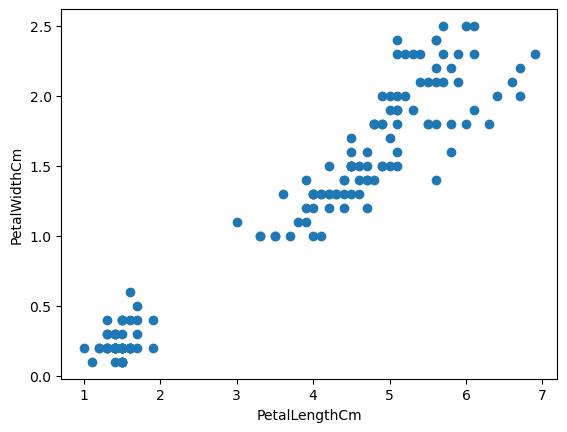

In [3]:
# positional indexing on a DataFrame
xs = iris_df.iloc[:, 3]
ys = iris_df.iloc[:, 4]

plt.scatter(xs, ys)
plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
plt.show()

In [4]:
# Performing k-Means clustering and predicted the labels of new points
iris = load_iris()
points = iris.data 

In [5]:
# create a KMeans instance with 3 clusters (Iris has 3 species)
model = KMeans(n_clusters=3, n_init=10)

# fit and predict on the same data — no separate new_points needed
labels = model.fit_predict(points)

# print cluster labels
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


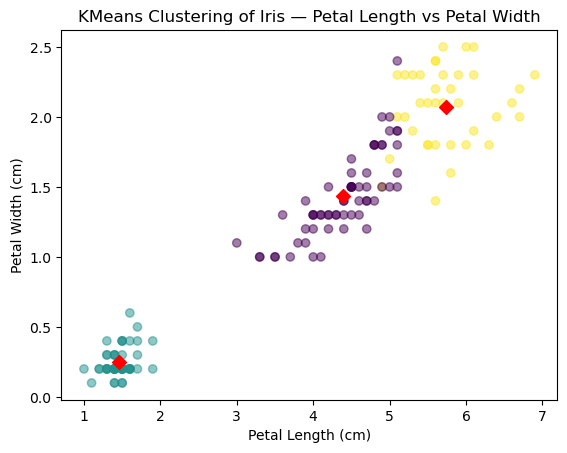

In [6]:
# Assign the columns of points: xs and ys (using petal length/width, indices 2 and 3)
xs = points[:, 2]
ys = points[:, 3]

# Make a scatter plot of xs and ys, using labels to define the colors
plt.scatter(xs, ys, c=labels, alpha=0.5)

# Assign the cluster centers: centroids
centroids = model.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y (same feature columns as xs/ys)
centroids_x = centroids[:, 2]
centroids_y = centroids[:, 3]

# Make a scatter plot of centroids_x and centroids_y
plt.scatter(centroids_x, centroids_y, marker='D', s=50, c='red')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('KMeans Clustering of Iris — Petal Length vs Petal Width')
plt.show()

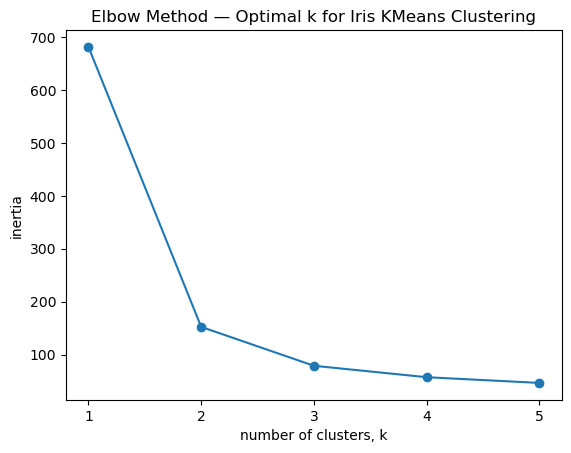

In [7]:
# Range of k values to try (elbow method for choosing optimal clusters)
samples_iris = points
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters
    model = KMeans(n_clusters=k, n_init=10)
    # Fit model to samples
    model.fit(samples_iris)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias (outside the loop — runs once after all k values tested)
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.title('Elbow Method — Optimal k for Iris KMeans Clustering')
plt.show()

The code runs KMeans clustering with k values from 1 to 5, recording each model's inertia (a measure of cluster tightness), then plots k against inertia to visually identify the "elbow" — the point where increasing k stops meaningfully reducing inertia — giving us a data-driven estimate for the optimal number of clusters rather than guessing arbitrarily. It looks like 3 clusters are the appropriate number of clusters for this dataset. 

In [8]:
# map numeric target labels (0,1,2) to their actual species names

# Create a KMeans model with 3 clusters
varieties = pd.Categorical.from_codes(iris.target, iris.target_names)
model = KMeans(n_clusters=3, n_init=10)  

# Fit model and obtain cluster labels in one step
labels = model.fit_predict(samples_iris)

# Create a DataFrame with labels and varieties as columns
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

# Create crosstab: cross-tabulate cluster labels against real variety names
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
print(ct)

varieties  setosa  versicolor  virginica
labels                                  
0               0           2         36
1              50           0          0
2               0          48         14


The crosstab shows that KMeans did a strong job rediscovering the true species groupings without ever seeing the labels: cluster 1 is a near-perfect match for setosa (all 50 samples), cluster 2 captures most of versicolor (48 of 50) with a few virginica mixed in, and cluster 0 is dominated by virginica (36 of 50) but picks up some versicolor overlap too — so the model cleanly separates setosa from the other two species, while versicolor and virginica, which are known to overlap more in feature space, get slightly blended between clusters 0 and 2.

In [9]:
# Load Palmer Penguins dataset
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(url)

# Drop rows with missing values 
penguins = penguins.dropna()
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
4       3450.0  female  2007  
5       3650.0    male  2007  


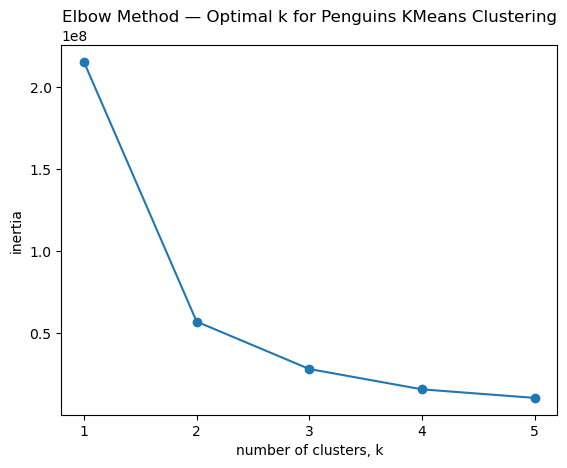

In [10]:
# Range of k values to try (elbow method for choosing optimal clusters)
samples_penguins = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values  # penguins features

ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters
    model = KMeans(n_clusters=k, n_init=10)
    # Fit model to samples
    model.fit(samples_penguins)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias (outside the loop — runs once after all k values tested)
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.title('Elbow Method — Optimal k for Penguins KMeans Clustering')
plt.show()

In [11]:
print(samples_penguins[:5])

# Ground-truth species labels for later comparison
species = penguins['species'].values

[[  39.1   18.7  181.  3750. ]
 [  39.5   17.4  186.  3800. ]
 [  40.3   18.   195.  3250. ]
 [  36.7   19.3  193.  3450. ]
 [  39.3   20.6  190.  3650. ]]


In [12]:
# Create scaler: scaler
scaler = StandardScaler()  # transforming features to have mean 0 and std of 1 so all features have equal weight
# standardizes features by removing the mean and scaling to unit variance

# Create KMeans instance: kmeans
kmeans = KMeans(n_clusters=3, n_init=10)  # 3 clusters to match the 3 known penguin species

# Create pipeline: pipeline
pipeline = make_pipeline(scaler, kmeans)

In [13]:
# Fit the pipeline to samples
pipeline.fit(samples_penguins)

# Calculate the cluster labels: labels
labels = pipeline.predict(samples_penguins)

# Create a DataFrame with labels and species as columns: df
df = pd.DataFrame({'labels': labels, 'species': species})

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['species'])

# Display ct
print(ct)

species  Adelie  Chinstrap  Gentoo
labels                            
0            22         63       0
1             0          0     119
2           124          5       0


KMeans successfully rediscovered the real penguin species almost entirely from just physical measurements, with no access to the species labels themselves: Gentoo forms a perfectly isolated cluster (cluster 1, 119 pure Gentoo), Adelie is nearly as clean (cluster 0, 124 of 146 Adelie with only minor Chinstrap bleed-through), while the only real confusion is between Adelie and Chinstrap in cluster 2 — a known overlap in bill and body measurements between these two species, reflecting genuine biological similarity rather than a clustering failure.

In [14]:
# raw price data: rows = companies, columns = dates, values = daily closing price
url = 'https://raw.githubusercontent.com/mesfind/datasets/master/company-stock-movements-2010-2015-incl.csv'
stocks_df = pd.read_csv(url, index_col=0)

print(stocks_df.head())

                  2010-01-04  2010-01-05  2010-01-06  2010-01-07  2010-01-08  \
Apple               0.580000   -0.220005   -3.409998   -1.170000    1.680011   
AIG                -0.640002   -0.650000   -0.210001   -0.420000    0.710001   
Amazon             -2.350006    1.260009   -2.350006   -2.009995    2.960006   
American express    0.109997    0.000000    0.260002    0.720002    0.190003   
Boeing              0.459999    1.770000    1.549999    2.690003    0.059997   

                  2010-01-11  2010-01-12  2010-01-13  2010-01-14  2010-01-15  \
Apple              -2.689994   -1.469994    2.779997   -0.680003   -4.999995   
AIG                -0.200001   -1.130001    0.069999   -0.119999   -0.500000   
Amazon             -2.309997   -1.640007    1.209999   -1.790001   -2.039994   
American express   -0.270001    0.750000    0.300004    0.639999   -0.130001   
Boeing             -1.080002    0.360000    0.549999    0.530002   -0.709999   

                  ...  2013-10-16  201

In [15]:
movements = stocks_df.values

In [16]:
# Create a normalizer: normalizer which rescales each sample
normalizer = Normalizer()

# Create a KMeans model with 10 clusters: kmeans
kmeans = KMeans(n_clusters = 10, n_init = 10)

# Make a pipeline chaining normalizer and kmeans: pipeline
pipeline = make_pipeline(normalizer, kmeans)

# Fit pipeline to the daily price movements
pipeline.fit(movements)

Pipeline(steps=[('normalizer', Normalizer()),
                ('kmeans', KMeans(n_clusters=10, n_init=10))])

In [17]:
# Extract company names from the DataFrame's index (row labels) as a plain array
companies = stocks_df.index.values

# Predict the cluster labels: labels
labels = pipeline.predict(movements)

# Create a DataFrame aligning labels and companies: df
df = pd.DataFrame({'labels': labels, 'companies': companies})

# Display df sorted by cluster label
print(df.sort_values('labels'))

    labels                           companies
30       0                          MasterCard
29       1                     Lookheed Martin
47       1                            Symantec
51       1                   Texas instruments
36       1                    Northrop Grumman
33       1                           Microsoft
32       1                                  3M
31       1                           McDonalds
58       1                               Xerox
50       1  Taiwan Semiconductor Manufacturing
23       1                                 IBM
20       1                          Home Depot
14       1                                Dell
24       1                               Intel
4        1                              Boeing
13       1                   DuPont de Nemours
11       1                               Cisco
8        1                         Caterpillar
25       2                   Johnson & Johnson
39       2                              Pfizer
56       2   

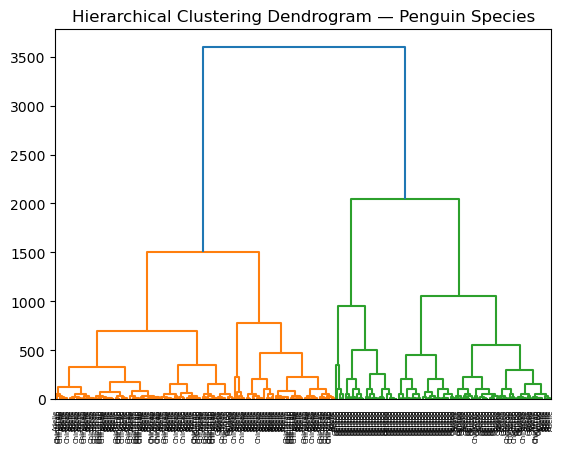

In [18]:
# Extract ground-truth species labels for dendrogram x-axis labeling (not used in clustering itself)
varieties = penguins['species'].tolist()

# Calculate the linkage: mergings (hierarchical clustering using complete linkage method)
mergings_penguins = linkage(samples_penguins, method='complete')

# Plot the dendrogram, using species varieties as leaf labels
dendrogram(mergings_penguins,
           labels=varieties,
           leaf_rotation=90,   # rotate labels 90 degrees so they don't overlap
           leaf_font_size=5)   # small font size to fit all labels given the sample size

plt.title('Hierarchical Clustering Dendrogram — Penguin Species')
plt.show()

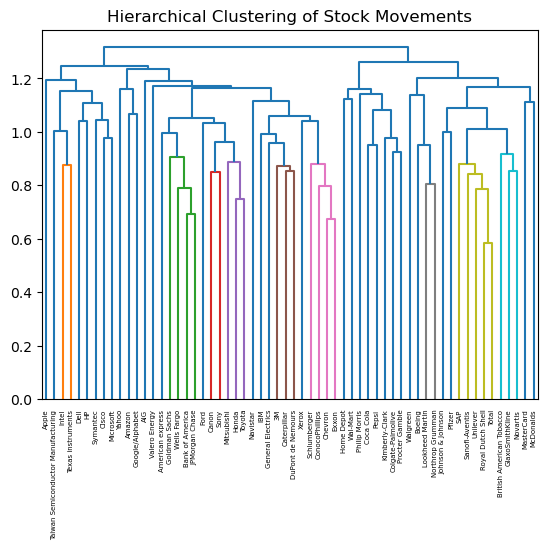

In [19]:
# Normalize the movements: normalized_movements
normalized_movements = normalize(movements)

# Calculate the linkage: mergings
mergings = linkage(normalized_movements, method='complete')

# Plot the dendrogram
dendrogram(mergings,
           labels=companies,
           leaf_rotation=90,   # rotate labels 90 degrees so they don't overlap
           leaf_font_size=5)   # small font size to fit all labels given the sample size
plt.title('Hierarchical Clustering of Stock Movements')
plt.show()

The linkage method defines how the distance between clusters is measured. In complete linkage, the distance between clusters is the distance between the furthest points of the clusters. In single linkage, the distance between clusters is the distance between the closest points of the clusters.

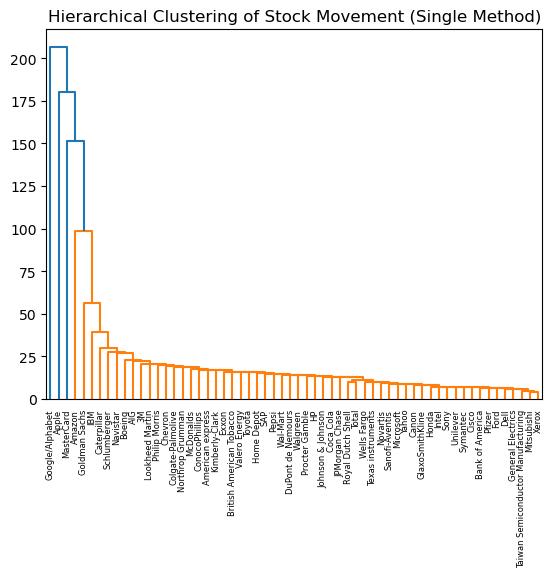

In [20]:
# Calculate the linkage: mergings
mergings = linkage(movements, method = 'single')

# Plot the dendrogram
plt.title('Hierarchical Clustering of Stock Movement (Single Method)')
dendrogram(mergings, labels = companies, leaf_rotation = 90, leaf_font_size = 6)
plt.show()

In [21]:
# Use fcluster to extract labels: labels
labels = fcluster(mergings_penguins, 1000, criterion='distance')

# Create a DataFrame with labels and varieties as columns: df
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
print(ct)

varieties  Adelie  Chinstrap  Gentoo
labels                              
1              71         44       5
2              51         17       0
3               0          0      42
4               0          0      38
5              24          7      34


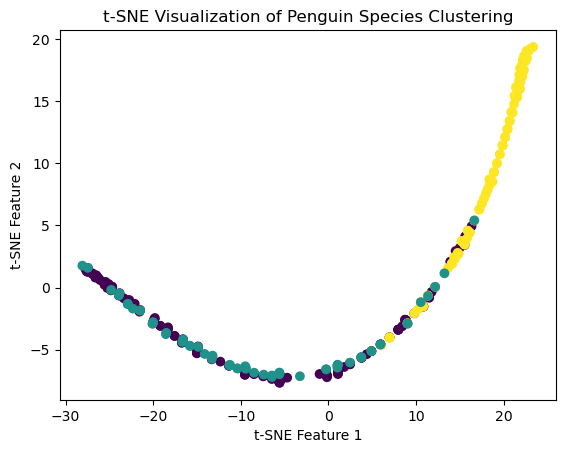

In [22]:
# Create a TSNE instance: model
model = TSNE(learning_rate=200)

# Apply fit_transform to samples: tsne_features
tsne_features = model.fit_transform(samples_penguins)

# Select the 0th feature: xs
xs = tsne_features[:, 0]

# Select the 1st feature: ys
ys = tsne_features[:, 1]

# variety_numbers needed for coloring — map species names to numeric codes
variety_numbers = penguins['species'].astype('category').cat.codes

# Scatter plot, coloring by variety_numbers
plt.scatter(xs, ys, c=variety_numbers)
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.title('t-SNE Visualization of Penguin Species Clustering')
plt.show()

This introduces **t-SNE (t-distributed Stochastic Neighbor Embedding)** — a dimensionality reduction technique used purely for visualization, not clustering itself. It takes your high-dimensional data (4 features for Penguins) and compresses it down to 2D in a way that tries to preserve the local structure/neighborhoods from the original space, so visually similar points in 2D likely were similar in the original 4D space too.


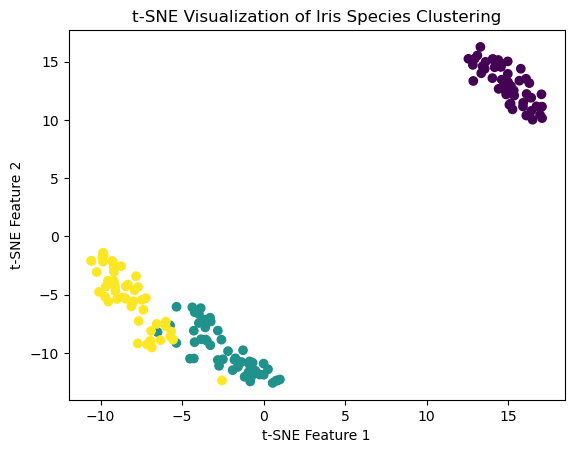

In [23]:
# Create a TSNE instance: model
model = TSNE(learning_rate=100)

# Apply fit_transform to samples: tsne_features
tsne_features = model.fit_transform(samples_iris)

# Select the 0th feature: xs
xs = tsne_features[:, 0]

# Select the 1st feature: ys
ys = tsne_features[:, 1]

# variety_numbers
variety_numbers = iris.target

# Scatter plot, coloring by variety_numbers
plt.scatter(xs, ys, c=variety_numbers)
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.title('t-SNE Visualization of Iris Species Clustering')
plt.show()

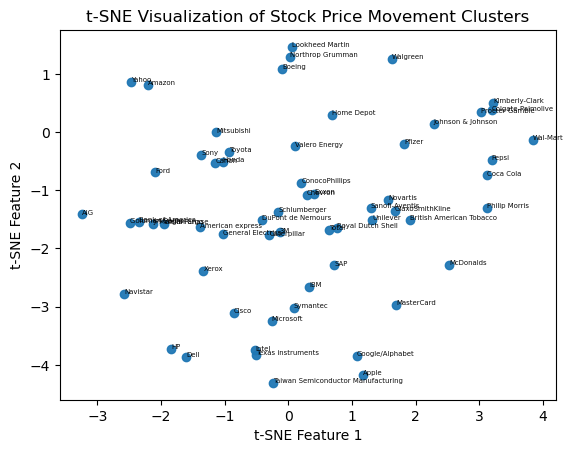

In [24]:
# Create a TSNE instance: model
model = TSNE(learning_rate = 50)

# Apply fit_transform to normalized_movements: tsne_features
tsne_features = model.fit_transform(normalized_movements)

# Select the 0th feature: xs
xs = tsne_features[:, 0]

# Select the 1th feature: ys
ys = tsne_features[:,1]

# Scatter plot
plt.scatter(xs, ys, alpha = 0.95)

# Annotate the points
for x, y, company in zip(xs, ys, companies):
    plt.annotate(company, (x, y), fontsize=5, alpha=0.95)

plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.title('t-SNE Visualization of Stock Price Movement Clusters')
plt.show()


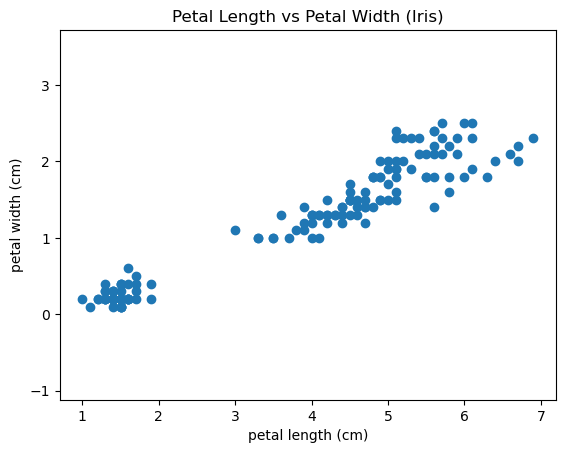

0.962757097050967


In [25]:
# Assign the 3rd column of iris_df: sepal_length
petal_length  = iris_df.iloc[:, 3]  # .iloc needed - DataFrame, not a numpy array
# Assign the 4th column of iris_df: sepal_width
petal_width = iris_df.iloc[:, 4]


# Scatter plot sepal_length vs sepal_width
plt.scatter(x=petal_length, y=petal_width)
plt.axis('equal')

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Petal Length vs Petal Width (Iris)')
plt.show()

# Calculate the Pearson correlation
correlation, pvalue = pearsonr(petal_length, petal_width)

# Display the correlation
print(correlation)

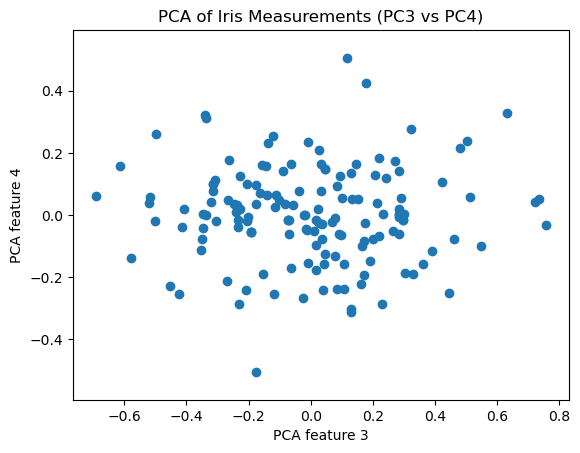

2.413286991182674e-16


In [26]:
# Create PCA instance: model
model = PCA()

# Apply the fit_transform method of model to the numeric iris features: pca_features
numeric_features = iris_df.drop(columns=['Id', 'Species'])  # drop row-id and label, keep only measurements
pca_features = model.fit_transform(numeric_features)

# Assign 2nd column of pca_features: xs
xs = pca_features[:, 2]

# Assign 3rd column of pca_features: ys
ys = pca_features[:, 3]

# Scatter plot xs vs ys
plt.scatter(xs, ys)
plt.axis('equal')

plt.xlabel('PCA feature 3')
plt.ylabel('PCA feature 4')
plt.title('PCA of Iris Measurements (PC3 vs PC4)')
plt.show()

# Calculate the Pearson correlation of xs and ys
correlation, pvalue = pearsonr(xs, ys)

# Display the correlation
print(correlation)

Petal length and petal width, taken directly from the raw data, are strongly correlated (~0.9) — bigger flowers tend to have both longer and wider petals, so the two columns are partly redundant, each telling us some of the same thing.
PCA fixes that redundancy by rotating the four original measurements into four new axes, ordered by how much variance they explain. PC1 and PC2 carry most of the real structure — enough to likely separate the iris species — while PC3 and PC4 are mostly just noise. But no matter which pair we check, PC1/PC2 or PC3/PC4, the correlation comes out at ~0 (the 1e-16 values are floating-point rounding, not signal). That's not because PCA happened to remove correlation from the important components — it's a mathematical guarantee that every pair of principal components is orthogonal, regardless of how much variance each one carries.
Nutshell: raw features can be highly correlated and redundant, but PCA's output never is — that's the entire reason to use it.

The **first principal component** of the data is the direction in which the data varies the most.

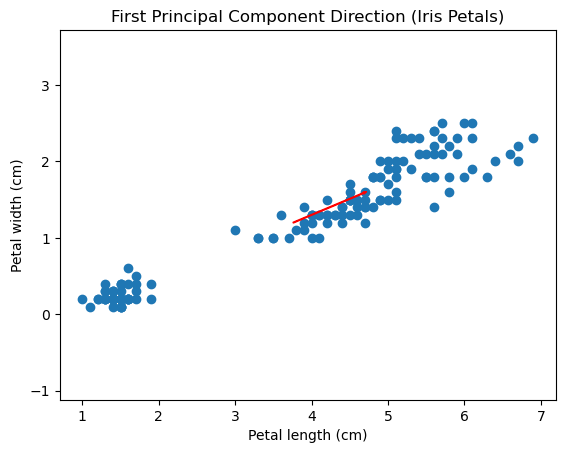

In [27]:
# Assign petal length and petal width columns as a numpy array
iris = iris_df[['PetalLengthCm', 'PetalWidthCm']].values  # .values converts DataFrame slice to numpy array

# Make a scatter plot of the untransformed points
plt.scatter(iris[:, 0], iris[:, 1])

# Create a PCA instance: model
model = PCA()

# Fit model to points
model.fit(iris)

# Get the mean of the petal measurements: mean
mean = model.mean_

# Get the first principal component: first_pc
first_pc = model.components_[0, :]

# Plot first_pc as an arrow, starting at mean
plt.arrow(mean[0], mean[1], first_pc[0], first_pc[1], color='red', width=0.01)

# Keep axes on same scale
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('First Principal Component Direction (Iris Petals)')
plt.axis('equal')
plt.show()

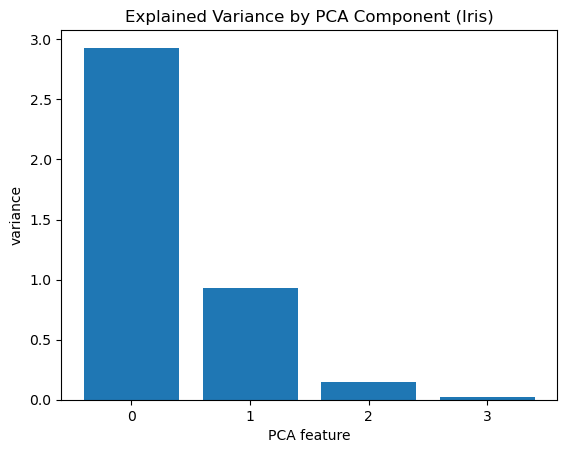

In [28]:
# Assign the numeric iris features: samples
samples = iris_df.drop(columns=['Id', 'Species'])  # drop row-id and label, keep only measurements

# Create scaler: scaler
scaler = StandardScaler()

# Create a PCA instance: pca
pca = PCA()

# Create pipeline: pipeline
pipeline = make_pipeline(scaler, pca)

# Fit the pipeline to 'samples'
pipeline.fit(samples)

# Plot the explained variances
features = range(pca.n_components_)
plt.bar(x=features, height=pca.explained_variance_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.title('Explained Variance by PCA Component (Iris)')
plt.xticks(features)
plt.show()

**Analysis:** the pipeline chains StandardScaler (putting all four measurements on the same scale) with PCA, then plots how much variance each principal component explains. The bar chart should show PC1 towering over the rest — since petal length and width are so strongly correlated (~0.9), most of the real signal collapses into that first component — while PC3 and PC4 barely register, consistent with the near-zero correlation we saw when comparing them earlier. In short, this chart is the numeric proof behind everything we found visually: a handful of components carry almost all the meaningful information, and the rest is close to noise.

In [29]:
# Create a PCA model with 2 components: pca
pca = PCA(n_components =2)

# Fit the PCA instance to the scaled samples
pca.fit(samples)

# Transform the scaled samples: pca_features
pca_features = pca.transform(samples)

# Print the shape of pca_features
print(pca_features.shape)


(150, 2)


In [30]:
document = [
    "Machine learning models learn patterns from data to make predictions.",
    "Natural language processing enables computers to understand human text.",
    "Deep learning uses neural networks with many layers to model complex patterns.",
    "Data preprocessing and cleaning are essential steps before training any model.",
    "Supervised learning uses labeled data, while unsupervised learning finds structure without labels."
]

In [31]:
# Create a TfidfVectorizer: tfidf
tfidf = TfidfVectorizer() 
# Apply fit_transform to document: csr_mat
csr_mat = tfidf.fit_transform(document)
# Print result of toarray() method
print(csr_mat.toarray())
# Get the words: words
words = tfidf.get_feature_names_out()
# Print words
print(words)

[[0.         0.         0.         0.         0.         0.
  0.         0.23683127 0.         0.         0.         0.
  0.3536317  0.         0.         0.         0.         0.
  0.3536317  0.23683127 0.3536317  0.3536317  0.         0.
  0.3536317  0.         0.         0.         0.28530783 0.3536317
  0.         0.         0.         0.         0.         0.
  0.23683127 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.34404072 0.         0.         0.34404072 0.         0.
  0.         0.34404072 0.         0.         0.34404072 0.
  0.         0.         0.         0.         0.         0.
  0.         0.34404072 0.         0.         0.         0.
  0.         0.34404072 0.         0.         0.         0.34404072
  0.23040808 0.         0.34404072 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.31863012
  0.         0.         0.3

In [32]:
# Sample articles - 6 ML pieces across 3 subtopics: neural nets, classical ML, NLP
articles = [
    "Neural networks learn patterns by adjusting weights through backpropagation.",
    "Deep learning models stack many layers to capture complex, non-linear patterns.",
    "Convolutional neural networks are widely used for image recognition tasks.",
    "Decision trees split data on feature thresholds to make predictions.",
    "Random forests combine many decision trees to reduce overfitting and improve accuracy.",
    "Transformers use attention mechanisms to process language and understand context."
]

titles = [
    "Understanding Neural Networks",
    "Why Deep Learning Needs Many Layers",
    "CNNs for Image Recognition",
    "How Decision Trees Make Predictions",
    "Random Forests Explained",
    "Attention and the Rise of Transformers"
]

# Vectorize text into TF-IDF features
tfidf = TfidfVectorizer()
csr_mat = tfidf.fit_transform(articles)

In [33]:
# Create a TruncatedSVD instance: svd (n_components must be less than number of features)
svd = TruncatedSVD(n_components=3)

# Create a KMeans instance: kmeans
kmeans = KMeans(n_clusters=3, n_init=10)  # n_init set explicitly to silence sklearn's default-change warning

# Create a pipeline: pipeline
pipeline = make_pipeline(svd, kmeans)

# Fit the pipeline to the TF-IDF matrix
pipeline.fit(csr_mat)

Pipeline(steps=[('truncatedsvd', TruncatedSVD(n_components=3)),
                ('kmeans', KMeans(n_clusters=3, n_init=10))])

In [34]:
# Calculate the cluster labels: labels
labels = pipeline.predict(csr_mat)

# Create a DataFrame aligning labels and titles: df
df = pd.DataFrame({'label': labels, 'article': titles})

# Display df sorted by cluster label
print(df.sort_values('label'))

   label                                 article
3      0     How Decision Trees Make Predictions
4      0                Random Forests Explained
5      0  Attention and the Rise of Transformers
0      1           Understanding Neural Networks
2      1              CNNs for Image Recognition
1      2     Why Deep Learning Needs Many Layers
